In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print('✅ Import xong!')

✅ Import xong!


In [2]:
# ⚠️ Sửa tên file nếu cần
FILE_PATH = 'paysim.csv'

df = pd.read_csv(r'D:\fraud_detection\data\paysim.csv')

print(f'Shape: {df.shape}')
print(f'\nCác cột: {list(df.columns)}')
df.head()

Shape: (1048575, 11)

Các cột: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
# Khám phá nhanh
print('=== Phân phối loại giao dịch ===')
print(df['type'].value_counts())

print('\n=== Tỷ lệ fraud ===')
print(df['isFraud'].value_counts(normalize=True).round(4))

print('\n=== Fraud theo type ===')
print(df.groupby('type')['isFraud'].sum())

=== Phân phối loại giao dịch ===
type
CASH_OUT    373641
PAYMENT     353873
CASH_IN     227130
TRANSFER     86753
DEBIT         7178
Name: count, dtype: int64

=== Tỷ lệ fraud ===
isFraud
0    0.9989
1    0.0011
Name: proportion, dtype: float64

=== Fraud theo type ===
type
CASH_IN       0
CASH_OUT    578
DEBIT         0
PAYMENT       0
TRANSFER    564
Name: isFraud, dtype: int64


In [4]:
def create_features(df):
    """
    Tạo 4 features mới cho PaySim:
    - balance_diff      : chênh lệch số dư trước/sau (bất thường = fraud)
    - amount_ratio      : tỷ lệ giao dịch / số dư ban đầu (gần 1.0 = fraud)
    - step_group        : nhóm thời gian trong ngày (0=đêm, 1=sáng, 2=chiều, 3=tối)
    - recipient_new_flag: tài khoản nhận mới (oldbalanceDest = 0)
    """
    df = df.copy()

    # 1. balance_diff
    # Nếu bình thường: oldbalanceOrg - amount == newbalanceOrig
    # Nếu fraud: thường drain hết tài khoản, diff != 0
    df['balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']

    # 2. amount_ratio
    df['amount_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)  # +1 tránh chia 0

    # 3. step_group — nhóm theo ca trong ngày
    # step là giờ (0-743 = 31 ngày), lấy mod 24 ra giờ trong ngày, chia 6 ra 4 ca
    df['step_group'] = (df['step'] % 24) // 6
    # 0=đêm(0-5h), 1=sáng(6-11h), 2=chiều(12-17h), 3=tối(18-23h)

    # 4. recipient_new_flag
    df['recipient_new_flag'] = (df['oldbalanceDest'] == 0).astype(int)

    return df

df = create_features(df)

print('✅ Đã tạo 4 features mới:')
df[['balance_diff', 'amount_ratio', 'step_group', 'recipient_new_flag']].describe().round(4)

✅ Đã tạo 4 features mới:


,balance_diff,amount_ratio,step_group,recipient_new_flag
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,-1.784663e+05,5.586388e+04,2.098100e+00,4.169000e-01
std,2.812392e+05,1.833115e+05,7.847000e-01,4.930000e-01
min,-6.388051e+06,0.000000e+00,0.000000e+00,0.000000e+00
25%,-2.508190e+05,1.820000e-01,2.000000e+00,0.000000e+00
50%,-6.748822e+04,5.606200e+00,2.000000e+00,0.000000e+00
75%,-1.517990e+03,1.094743e+04,3.000000e+00,1.000000e+00
max,8.802473e+04,5.860863e+06,3.000000e+00,1.000000e+00


In [5]:
new_features = ['balance_diff', 'amount_ratio', 'step_group', 'recipient_new_flag']

print('=== Trung bình theo nhãn fraud ===')
print(df.groupby('isFraud')[new_features].mean().round(4))

=== Trung bình theo nhãn fraud ===
         balance_diff  amount_ratio  step_group  recipient_new_flag
isFraud                                                            
0        -178652.2547    55916.6303      2.0986              0.4166
1          -7937.0319     7484.3235      1.6296              0.6375


In [6]:
# Encode transaction type
df['type_encoded'] = df['type'].map({
    'PAYMENT': 0, 'TRANSFER': 1, 'CASH_OUT': 2,
    'DEBIT': 3, 'CASH_IN': 4
})

# Chỉ lấy TRANSFER + CASH_OUT (nơi fraud xảy ra trong PaySim)
df_model = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
print(f'Số dòng sau lọc: {len(df_model):,}')
print(f'Fraud rate: {df_model["isFraud"].mean():.4f}')

feature_cols = [
    'amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'type_encoded',
    # 4 features mới
    'balance_diff',
    'amount_ratio',
    'step_group',
    'recipient_new_flag'
]

X = df_model[feature_cols]
y = df_model['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')

Số dòng sau lọc: 460,394
Fraud rate: 0.0025

Train: (368315, 10) | Test: (92079, 10)


In [7]:
# Tính scale_pos_weight để xử lý imbalanced data
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale:.1f} (xử lý imbalance)')

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

model.fit(X_train, y_train)
print('✅ Train xong!')

scale_pos_weight = 402.0 (xử lý imbalance)
✅ Train xong!


=== Classification Report ===
              precision    recall  f1-score   support

 Không fraud       1.00      1.00      1.00     91851
       Fraud       0.87      0.97      0.92       228

    accuracy                           1.00     92079
   macro avg       0.94      0.98      0.96     92079
weighted avg       1.00      1.00      1.00     92079

F1-score (fraud class): 0.9189


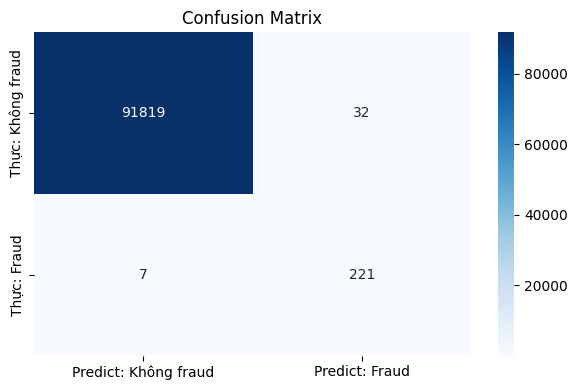

In [8]:
y_pred = model.predict(X_test)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Không fraud', 'Fraud']))
print(f'F1-score (fraud class): {f1_score(y_test, y_pred):.4f}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predict: Không fraud', 'Predict: Fraud'],
            yticklabels=['Thực: Không fraud', 'Thực: Fraud'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

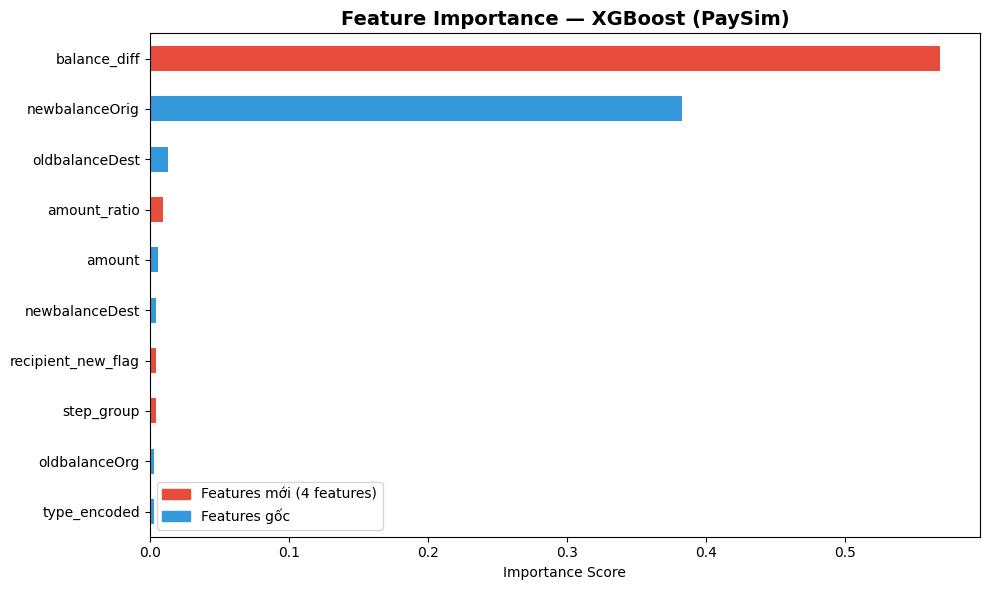

In [9]:
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=False)

# Tô màu đỏ cho 4 features mới
new_features = ['balance_diff', 'amount_ratio', 'step_group', 'recipient_new_flag']
colors = ['#e74c3c' if f in new_features else '#3498db'
          for f in importances_sorted.sort_values().index]

fig, ax = plt.subplots(figsize=(10, 6))
importances_sorted.sort_values().plot(
    kind='barh', ax=ax, color=colors
)
ax.set_title('Feature Importance — XGBoost (PaySim)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')

# Chú thích màu
from matplotlib.patches import Patch
legend = [
    Patch(color='#e74c3c', label='Features mới (4 features)'),
    Patch(color='#3498db', label='Features gốc')
]
ax.legend(handles=legend)
plt.tight_layout()
plt.show()

In [10]:
print('=== Rank của 4 features mới ===')
print(f'{"Feature":<25} {"Rank":<8} {"Score":<10} {"Kết quả"}')
print('-' * 55)

for f in new_features:
    rank = importances_sorted.index.get_loc(f) + 1
    score = importances_sorted[f]
    status = '✅ Lọt top 10' if rank <= 10 else '❌ Chưa lọt — xem lại cách tính'
    print(f'{f:<25} #{rank:<7} {score:<10.4f} {status}')

=== Rank của 4 features mới ===
Feature                   Rank     Score      Kết quả
-------------------------------------------------------
balance_diff              #1       0.5688     ✅ Lọt top 10
amount_ratio              #4       0.0098     ✅ Lọt top 10
step_group                #8       0.0042     ✅ Lọt top 10
recipient_new_flag        #7       0.0042     ✅ Lọt top 10
